# EP.4 PPO：从 MDP、GAE 到 token-level RLHF

配套文章：[从零理解 PPO](https://momoyeyu.github.io/posts/llm-ppo/)。上一章：[03_position.ipynb](03_position.ipynb)。本章沿用 [EP.0](00_transformer.ipynb) 定义的 `set_seed` / `show`，不调用隐藏训练器：环境物理、损失、采样 buffer、更新循环全部在眼前。短运行用于检查采样与更新流程，不用于证明收敛；完整训练见 `trainer` CLI。

In [1]:
from pathlib import Path
import sys

root = Path.cwd()
if not (root / "slm").is_dir():
    root = next((parent for parent in root.parents if (parent / "slm").is_dir()), None)
if root is None:
    raise RuntimeError("请从仓库根目录或 notebooks 目录运行")
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from slm import set_seed, show

torch.set_num_threads(1)
set_seed(0)
show("Python", sys.version.split()[0])
show("PyTorch", torch.__version__)
show("device", "cpu")
import copy
import random
import matplotlib.pyplot as plt
from torch.distributions import Categorical

Python                       3.12.12
PyTorch                      2.14.1
device                       cpu


## 1. MDP、轨迹与折扣回报

CartPole 的四维状态和物理更新完整展开。有限轨迹回报为 $G_t=\sum_k\gamma^k r_{t+k}$。

In [2]:
class CartPole:
    """手写的 CartPole，物理参数与 Gymnasium 的 CartPole-v1 一致。

    动作 0 / 1 表示向左 / 向右推小车；每坚持一步奖励为 1；
    杆子倾角超过 12° 或小车出界时 terminated，达到 max_steps 时 truncated。
    """

    def __init__(self, max_steps: int = 500) -> None:
        self.gravity, self.tau, self.force_mag = 9.8, 0.02, 10.0
        self.mass_cart, self.mass_pole, self.length = 1.0, 0.1, 0.5
        self.total_mass = self.mass_cart + self.mass_pole
        self.pole_mass_length = self.mass_pole * self.length
        self.theta_limit = 12 * 2 * math.pi / 360
        self.x_limit = 2.4
        self.max_steps = max_steps
        self.obs_dim, self.n_actions = 4, 2

    def reset(self) -> list[float]:
        self.state = [random.uniform(-0.05, 0.05) for _ in range(4)]
        self.t = 0
        return list(self.state)

    def step(self, action: int) -> tuple[list[float], float, bool, bool]:
        x, x_dot, theta, theta_dot = self.state
        force = self.force_mag if action == 1 else -self.force_mag
        cos, sin = math.cos(theta), math.sin(theta)
        temp = (force + self.pole_mass_length * theta_dot**2 * sin) / self.total_mass
        theta_acc = (self.gravity * sin - cos * temp) / (
            self.length * (4 / 3 - self.mass_pole * cos**2 / self.total_mass)
        )
        x_acc = temp - self.pole_mass_length * theta_acc * cos / self.total_mass
        x, x_dot = x + self.tau * x_dot, x_dot + self.tau * x_acc
        theta, theta_dot = theta + self.tau * theta_dot, theta_dot + self.tau * theta_acc
        self.state = [x, x_dot, theta, theta_dot]
        self.t += 1

        terminated = abs(x) > self.x_limit or abs(theta) > self.theta_limit
        truncated = self.t >= self.max_steps
        return list(self.state), 1.0, terminated, truncated

In [3]:
def discounted_returns(rewards: list[float], gamma: float) -> list[float]:
    """倒序递推 G_t = r_t + gamma * G_{t+1}。"""
    returns, G = [], 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.append(G)
    return returns[::-1]

In [4]:
def rollout(env: CartPole, policy) -> tuple[list[list[float]], list[int], list[float]]:
    """用任意 policy(state) -> action 采样一条完整轨迹。"""
    states, actions, rewards = [], [], []
    s, done = env.reset(), False
    while not done:
        a = policy(s)
        s_next, r, terminated, truncated = env.step(a)
        states.append(s)
        actions.append(a)
        rewards.append(r)
        s, done = s_next, terminated or truncated
    return states, actions, rewards

In [5]:
import random



set_seed(0)
env = CartPole()

# 倒序递推得到的回报，与逐项求和的定义完全一致
rewards, gamma = [1.0, 0.0, 2.0, 3.0], 0.9
show("discounted returns", [round(g, 4) for g in discounted_returns(rewards, gamma)])
show("by definition", [round(sum(gamma**k * rewards[t + k] for k in range(len(rewards) - t)), 4)
                       for t in range(len(rewards))])

# 两个基准策略：均匀随机、永远向右推
for name, policy in [("random", lambda s: random.randint(0, 1)), ("always right", lambda s: 1)]:
    lengths = [len(rollout(env, policy)[2]) for _ in range(1000)]
    show(f"{name} policy", f"avg episode length {sum(lengths) / len(lengths):.1f} over 1000 episodes")

discounted returns           [4.807, 4.23, 4.7, 3.0]
by definition                [4.807, 4.23, 4.7, 3.0]
random policy                avg episode length 22.5 over 1000 episodes
always right policy          avg episode length 9.4 over 1000 episodes


随机与恒向右策略只作基线。gamma 控制远期奖励权重；这里 episode 在 terminated 或 max_steps truncated 时结束，是明确的有限时域约定。

## 2. 价值函数：Bellman 精确解与 Monte Carlo 样本

五状态随机游走把边界设为终止状态，从中间 C 出发。

In [6]:
N_STATES = 7

In [7]:
START = N_STATES // 2

In [8]:
def walk_step(s: int) -> tuple[int, float]:
    s_next = s + random.choice([-1, 1])
    return s_next, 1.0 if s_next == N_STATES - 1 else 0.0

In [9]:
def is_terminal(s: int) -> bool:
    return not 0 < s < N_STATES - 1

In [10]:
def policy_evaluation(gamma: float = 1.0, tol: float = 1e-10) -> list[float]:
    V = [0.0] * N_STATES
    while True:
        delta = 0.0
        for s in range(1, N_STATES - 1):
            v_new = 0.0
            for s_next in (s - 1, s + 1):
                r = 1.0 if s_next == N_STATES - 1 else 0.0
                v_new += 0.5 * (r + gamma * V[s_next])
            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new
        if delta < tol:
            return V


def monte_carlo(num_episodes: int, gamma: float = 1.0) -> list[float]:
    total, count = [0.0] * N_STATES, [0] * N_STATES
    for _ in range(num_episodes):
        s, states, rewards = START, [], []
        while not is_terminal(s):
            s_next, r = walk_step(s)
            states.append(s)
            rewards.append(r)
            s = s_next
        for s, G in zip(states, discounted_returns(rewards, gamma)):
            total[s] += G
            count[s] += 1
    return [t / c if c else 0.0 for t, c in zip(total, count)]


if __name__ == "__main__":
    set_seed(0)
    V = policy_evaluation()
    V_mc = monte_carlo(10000)
    show("true value", [round(i / 6, 4) for i in range(1, 6)])
    show("Bellman", [round(v, 4) for v in V[1:-1]])
    show("Monte Carlo", f"{[round(v, 4) for v in V_mc[1:-1]]} (max error {max(abs(V_mc[i] - i / 6) for i in range(1, 6)):.4f})")
    # 在 C 处：Q(C, 右) = 0 + V(D)，Q(C, 左) = 0 + V(B)
    show("advantages at C", f"right {V[4] - V[3]:+.4f}, left {V[2] - V[3]:+.4f}")

true value                   [0.1667, 0.3333, 0.5, 0.6667, 0.8333]
Bellman                      [0.1667, 0.3333, 0.5, 0.6667, 0.8333]
Monte Carlo                  [0.1652, 0.3278, 0.4906, 0.6593, 0.8297] (max error 0.0094)
advantages at C              right +0.1667, left -0.1667


Bellman 迭代给出这个小 MDP 的数值解；Monte Carlo 是有限样本估计，因此只应接近而非逐位相等。

## 3. REINFORCE 与 baseline

策略梯度使用 score function $\nabla\log\pi(a|s)G$。与动作无关的 baseline 在期望上不改变梯度，却可改变采样方差。

In [11]:
def mlp(in_dim: int, out_dim: int, hidden: int = 64) -> nn.Sequential:
    return nn.Sequential(
        nn.Linear(in_dim, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, out_dim),
    )

In [12]:
class Policy(nn.Module):
    """REINFORCE 使用的策略网络：输出 logits，包装成 Categorical 分布。"""

    def __init__(self, obs_dim: int, n_actions: int) -> None:
        super().__init__()
        self.net = mlp(obs_dim, n_actions)

    def forward(self, obs: torch.Tensor) -> Categorical:
        return Categorical(logits=self.net(obs))

In [13]:
import torch


torch.manual_seed(0)
logits = torch.zeros(2, requires_grad=True)       # 初始策略：两个动作各 1/2
mean_reward = torch.tensor([10.0, 11.0])


def grad_estimate(n: int, baseline: float) -> torch.Tensor:
    dist = torch.distributions.Categorical(logits=logits)
    a = dist.sample((n,))
    r = mean_reward[a] + torch.randn(n)
    loss = -(dist.log_prob(a) * (r - baseline)).mean()
    (g,) = torch.autograd.grad(loss, logits)
    return -g                                      # 返回 ∇J 的估计


# 精确的策略梯度：∇J = Σ_a π(a) ∇log π(a) Q(a)
probs = torch.softmax(logits, -1)
exact = torch.autograd.grad((probs * mean_reward).sum(), logits)[0]
show("exact gradient", exact.tolist())

for b in (0.0, 10.5):
    grads = torch.stack([grad_estimate(16, b) for _ in range(2000)])
    show(f"baseline={b:4.1f}", f"mean {[round(x, 3) for x in grads.mean(0).tolist()]} | variance {[round(x, 3) for x in grads.var(0).tolist()]}")

exact gradient               [-0.25, 0.25]


baseline= 0.0                mean [-0.292, 0.292] | variance [1.739, 1.739]


baseline=10.5                mean [-0.252, 0.252] | variance [0.015, 0.015]


老虎机实验比较同一批量下的梯度均值与方差。有限样本均值不会严格等于精确梯度；结论针对 action-independent baseline 的期望。

## 4. Actor–Critic 与 GAE

TD residual 为 $\delta_t=r_t+\gamma V(s_{t+1})-V(s_t)$；GAE 递推 $A_t=\delta_t+\gamma\lambda A_{t+1}$。

In [14]:
def layer_init(layer: nn.Linear, std: float = math.sqrt(2)) -> nn.Linear:
    nn.init.orthogonal_(layer.weight, std)
    nn.init.zeros_(layer.bias)
    return layer

In [15]:
class ActorCritic(nn.Module):
    """PPO 使用的 Actor-Critic：两个独立的 MLP，正交初始化。"""

    def __init__(self, obs_dim: int, n_actions: int, hidden: int = 64) -> None:
        super().__init__()
        self.actor = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden)), nn.Tanh(),
            layer_init(nn.Linear(hidden, hidden)), nn.Tanh(),
            layer_init(nn.Linear(hidden, n_actions), std=0.01),
        )
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden)), nn.Tanh(),
            layer_init(nn.Linear(hidden, hidden)), nn.Tanh(),
            layer_init(nn.Linear(hidden, 1), std=1.0),
        )

    def forward(self, obs: torch.Tensor) -> tuple[Categorical, torch.Tensor]:
        return Categorical(logits=self.actor(obs)), self.critic(obs).squeeze(-1)

In [16]:
def compute_gae(
    rewards: torch.Tensor,  # [T]
    values: torch.Tensor,   # [T]
    dones: torch.Tensor,    # [T]，第 t 步之后回合是否结束
    last_value: torch.Tensor,
    gamma: float,
    lam: float,
) -> tuple[torch.Tensor, torch.Tensor]:
    """GAE：A_t = delta_t + gamma * lam * A_{t+1}，返回 (advantages, returns)。"""
    T = rewards.size(0)
    advantages = torch.zeros_like(rewards)
    gae = 0.0
    for t in reversed(range(T)):
        next_value = last_value if t == T - 1 else values[t + 1]
        mask = 1.0 - dones[t]
        delta = rewards[t] + gamma * next_value * mask - values[t]
        gae = delta + gamma * lam * mask * gae
        advantages[t] = gae
    returns = advantages + values
    return advantages, returns

In [17]:
import torch


set_seed(0)
T, gamma = 10, 0.9
rewards, values = torch.rand(T), torch.rand(T)
dones = torch.zeros(T)
dones[4] = dones[-1] = 1.0              # 两个回合：0..4 与 5..9
last_value = torch.tensor(0.7)

adv, ret = compute_gae(rewards, values, dones, last_value, gamma, lam=1.0)
G = torch.tensor(discounted_returns(rewards[:5].tolist(), gamma)
                 + discounted_returns(rewards[5:].tolist(), gamma))
show("lambda=1 Monte Carlo", (torch.allclose(adv, G - values), torch.allclose(ret, G)))

adv, _ = compute_gae(rewards, values, dones, last_value, gamma, lam=0.0)
next_values = torch.cat([values[1:], last_value.view(1)])
show("lambda=0 one-step TD", torch.allclose(adv, rewards + gamma * next_values * (1 - dones) - values))

# 最后一步回合未结束时，用 last_value 做 bootstrap
adv, _ = compute_gae(rewards, values, torch.zeros(T), last_value, gamma, lam=1.0)
G = torch.tensor(discounted_returns(rewards.tolist() + [last_value.item()], gamma)[:T])
show("bootstrap from V(s_T)", torch.allclose(adv, G - values, atol=1e-6))

lambda=1 Monte Carlo         (True, True)
lambda=0 one-step TD         True
bootstrap from V(s_T)        True


lambda=0 对应单步 TD，lambda=1 在 episode 边界对应 Monte Carlo；非终止末端用 last_value bootstrap。本项目把时间上限也当有限时域终止，不宣称等同 Gym 的无限时域 truncation 语义。

## 5. Importance sampling 与支持集

用行为分布 q 的样本估计 p 下期望，权重为 p(x)/q(x)。

In [18]:
def importance_sampling(p: torch.Tensor, q: torch.Tensor, f: torch.Tensor, n: int = 1000):
    """从行为分布 q 采样，估计 E_{x~p}[f(x)]，返回 (估计值, 重要性权重的标准差)。"""
    x = torch.multinomial(q, n, replacement=True)
    w = p[x] / q[x]
    return (w * f[x]).mean().item(), w.std().item()

In [19]:
import torch


set_seed(0)
p = torch.tensor([0.1, 0.2, 0.3, 0.4])
f = torch.tensor([1.0, 2.0, 3.0, 4.0])
show("true E_p[f]", f"{(p * f).sum().item():.4f}")
for name, q in [("q close to p", torch.tensor([0.15, 0.2, 0.3, 0.35])),
                ("q far from p", torch.tensor([0.7, 0.2, 0.07, 0.03]))]:
    est, w_std = importance_sampling(p, q, f, 100_000)
    show(name, f"estimate {est:.4f} | std of importance weights {w_std:.3f}")

true E_p[f]                  3.0000
q close to p                 estimate 3.0004 | std of importance weights 0.154
q far from p                 estimate 2.9623 | std of importance weights 2.389


q 必须在 p 非零处有完整支持，否则权重不可定义。q 与 p 相差大时，有限样本权重方差会增大。

## 6. PPO clipping：只截断“过度有利”的方向

先看正负 advantage 下超界 ratio 的梯度，再展开训练真正调用的损失。

In [20]:
import torch


eps = 0.2
log_prob = torch.tensor([0.0], requires_grad=True)
ratio = torch.exp(log_prob - torch.tensor([-0.5]))   # ρ ≈ 1.65，已超出 [1-ε, 1+ε]

for A in (1.0, -1.0):
    log_prob.grad = None
    adv = torch.tensor([A])
    obj = torch.min(ratio * adv, torch.clamp(ratio, 1 - eps, 1 + eps) * adv)
    obj.sum().backward(retain_graph=True)
    show(f"A={A:+.0f}, rho={ratio.item():.2f}", f"d obj / d log pi = {log_prob.grad.item():+.3f}")

A=+1, rho=1.65               d obj / d log pi = +0.000
A=-1, rho=1.65               d obj / d log pi = -1.649


In [21]:
def ppo_loss(
    model: ActorCritic,
    obs: torch.Tensor,            # [B, obs_dim]
    actions: torch.Tensor,        # [B]
    old_log_probs: torch.Tensor,  # [B]
    advantages: torch.Tensor,     # [B]
    returns: torch.Tensor,        # [B]
    clip_eps: float = 0.2,
    vf_coef: float = 0.5,
    ent_coef: float = 0.01,
) -> tuple[torch.Tensor, dict[str, float]]:
    dist, values = model(obs)
    log_probs = dist.log_prob(actions)
    ratio = torch.exp(log_probs - old_log_probs)

    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    surr1 = ratio * advantages
    surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * advantages
    policy_loss = -torch.min(surr1, surr2).mean()

    value_loss = F.mse_loss(values, returns)
    entropy = dist.entropy().mean()
    loss = policy_loss + vf_coef * value_loss - ent_coef * entropy

    with torch.no_grad():
        clip_frac = ((ratio - 1).abs() > clip_eps).float().mean().item()
        approx_kl = ((ratio - 1) - torch.log(ratio)).mean().item()
    return loss, {"clip_frac": clip_frac, "approx_kl": approx_kl}

PPO 对 `min(ratio*A, clip(ratio)*A)` 取负作 policy loss，并同时拟合 value、加入 entropy。clip fraction 与近似 KL 是诊断量，不是成功保证。

## 7. 一个完全展开的短 PPO 循环

下面依次采样 128 步、算 GAE、做两轮 minibatch 更新并画 episode return。常数保持小规模，目的只是看清数据流。

update 1                     loss 33.394 | clip 0.000
update 2                     loss 21.838 | clip 0.000
update 3                     loss 37.274 | clip 0.000
update 4                     loss 39.679 | clip 0.000
update 5                     loss 58.541 | clip 0.000
update 6                     loss 55.754 | clip 0.000
update 7                     loss 71.600 | clip 0.000
update 8                     loss 38.877 | clip 0.000


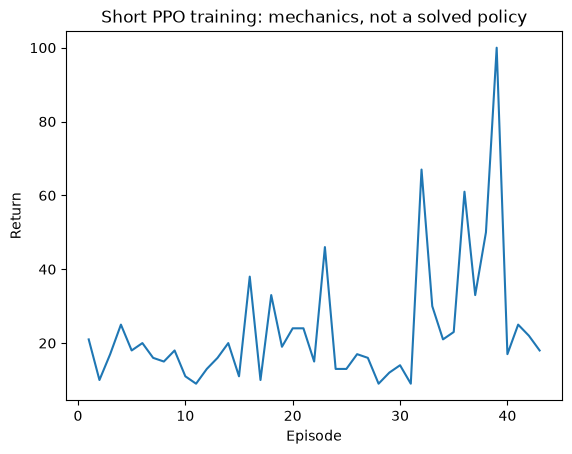

In [22]:
set_seed(0)
env = CartPole(max_steps=100)
agent = ActorCritic(4, 2)
optimizer = torch.optim.Adam(agent.parameters(), lr=3e-4, eps=1e-5)
state, episode, history = env.reset(), 0.0, []
for update in range(8):
    buffer = {name: [] for name in ('obs','actions','log_probs','values','rewards','dones')}
    for _ in range(128):
        obs = torch.tensor(state)
        with torch.no_grad():
            dist, value = agent(obs)
            action = dist.sample()
            log_prob = dist.log_prob(action)
        state, reward, terminated, truncated = env.step(action.item())
        done = terminated or truncated
        for name, value in zip(buffer, (obs,action,log_prob,value,reward,float(done))):
            buffer[name].append(value)
        episode += reward
        if done:
            history.append(episode)
            state, episode = env.reset(), 0.0
    obs, actions, old_probs, values = [torch.stack(buffer[name]) for name in ('obs','actions','log_probs','values')]
    rewards, dones = torch.tensor(buffer['rewards']), torch.tensor(buffer['dones'])
    with torch.no_grad():
        last = agent(torch.tensor(state))[1]
    advantages, returns = compute_gae(rewards, values, dones, last, 0.99, 0.95)
    for _ in range(2):
        for indices in torch.randperm(128).split(64):
            loss, info = ppo_loss(agent,obs[indices],actions[indices],old_probs[indices],advantages[indices],returns[indices])
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), 0.5)
            optimizer.step()
    show(f'update {update+1}', f'loss {loss.item():.3f} | clip {info["clip_frac"]:.3f}')
plt.plot(range(1,len(history)+1), history)
plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('Short PPO training: mechanics, not a solved policy')
plt.show()

曲线是当前随机种子下的真实记录；8 次 update 很可能波动或尚未学会。短运行用于检查采样、GAE 与 minibatch 更新是否连通，不用于证明收敛；完整训练见 `trainer/train_ppo.py`。

## 8. TinyLM：把 token 当 action

TinyLM 用 BOS + 前缀预测当前 token；GRU 主干由 policy logits 与 value head 共享。这个对齐约定不同于普通 causal LM 的 logits[t] 预测 t+1。

In [23]:
class TinyLM(nn.Module):
    """玩具 RLHF 用的小型 GRU 语言模型，Actor 与 Critic 共享主干。"""

    def __init__(self, vocab_size: int, hidden: int = 64) -> None:
        super().__init__()
        self.bos = vocab_size
        self.embed = nn.Embedding(vocab_size + 1, hidden)
        self.rnn = nn.GRU(hidden, hidden, batch_first=True)
        self.lm_head = nn.Linear(hidden, vocab_size)
        self.value_head = nn.Linear(hidden, 1)

    def forward(self, tokens: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # tokens: [B, L]，预测第 t 个 token 时只看得到 BOS 与前 t-1 个 token
        bos = torch.full_like(tokens[:, :1], self.bos)
        h, _ = self.rnn(self.embed(torch.cat([bos, tokens[:, :-1]], dim=1)))
        return self.lm_head(h), self.value_head(h).squeeze(-1)  # [B, L, V], [B, L]

    @torch.no_grad()
    def generate(self, batch_size: int, length: int) -> torch.Tensor:
        device = self.lm_head.weight.device
        x = torch.full((batch_size, 1), self.bos, device=device)
        h, tokens = None, []
        for _ in range(length):
            out, h = self.rnn(self.embed(x), h)
            x = Categorical(logits=self.lm_head(out[:, -1])).sample().unsqueeze(1)
            tokens.append(x)
        return torch.cat(tokens, dim=1)  # [B, L]

In [24]:
def token_log_probs(logits: torch.Tensor, tokens: torch.Tensor) -> torch.Tensor:
    return torch.log_softmax(logits, dim=-1).gather(-1, tokens.unsqueeze(-1)).squeeze(-1)

生成时每一步从 Categorical 采样；`token_log_probs` 从完整词表 logits 中取出已采样 token 的 log probability。

## 9. 直接展开的 token-level PPO/RLHF

冻结初始 policy 作 reference，用“token 是否等于 3”的比例作 score，并把 sampled log-ratio KL 惩罚分配到每一步。

RLHF iteration 1             score 0.148 | sampled KL 0.000
RLHF iteration 2             score 0.109 | sampled KL -0.000
RLHF iteration 3             score 0.109 | sampled KL 0.006
RLHF iteration 4             score 0.211 | sampled KL 0.061
RLHF iteration 5             score 0.141 | sampled KL 0.005
RLHF iteration 6             score 0.172 | sampled KL 0.022
RLHF iteration 7             score 0.133 | sampled KL -0.021
RLHF iteration 8             score 0.125 | sampled KL -0.029
RLHF iteration 9             score 0.188 | sampled KL 0.071
RLHF iteration 10            score 0.172 | sampled KL 0.036
RLHF iteration 11            score 0.188 | sampled KL 0.105
RLHF iteration 12            score 0.266 | sampled KL 0.227


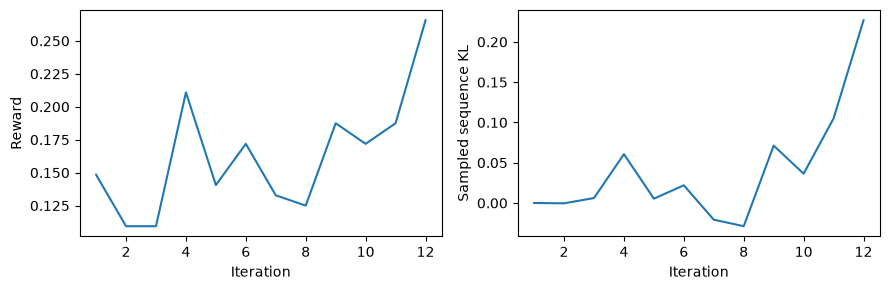

In [25]:
set_seed(0)
policy = TinyLM(8, hidden=32)
reference = copy.deepcopy(policy).eval().requires_grad_(False)
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)
records = []
for iteration in range(12):
    tokens = policy.generate(32, 4)
    with torch.no_grad():
        logits, values = policy(tokens)
        old_probs = token_log_probs(logits, tokens)
        ref_probs = token_log_probs(reference(tokens)[0], tokens)
    scores = (tokens == 3).float().mean(-1)
    kl = old_probs - ref_probs
    rewards = -0.1 * kl
    rewards[:, -1] += scores
    dones = torch.tensor([0.,0.,0.,1.])
    pairs = [compute_gae(rewards[i],values[i],dones,torch.tensor(0.),1.,0.95) for i in range(32)]
    advantages, returns = [torch.stack(items) for items in zip(*pairs)]
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    for _ in range(2):
        logits, new_values = policy(tokens)
        ratio = (token_log_probs(logits,tokens)-old_probs).exp()
        surrogate = torch.minimum(ratio*advantages, ratio.clamp(0.8,1.2)*advantages)
        loss = -surrogate.mean() + 0.5*F.mse_loss(new_values,returns)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    records.append((scores.mean().item(),kl.sum(-1).mean().item()))
    show(f'RLHF iteration {iteration+1}', f'score {records[-1][0]:.3f} | sampled KL {records[-1][1]:.3f}')
fig, axes = plt.subplots(1,2,figsize=(9,3))
for axis, index, label in zip(axes,(0,1),('Reward','Sampled sequence KL')):
    axis.plot(range(1,len(records)+1), [row[index] for row in records])
    axis.set(xlabel='Iteration',ylabel=label)
plt.tight_layout()
plt.show()

图展示真实 score 与 sampled sequence KL。小 batch 下 sampled KL 可以为负；reference 是冻结的随机初始网络，并非严格均匀分布，因此若另行推导均匀 reference 的闭式解，也不能直接当作本实验精确目标。